In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cpu")

In [2]:
# N is a Neural Network - This is exactly the network used by Lagaris et al. 1997
a = 1.3823
b = 191.0755
N = nn.Sequential(nn.Linear(1, 50), nn.Sigmoid(), nn.Linear(50,1, bias=False))

# Initial condition
A = 0.

# The Psi_t function/
x = lambda t: A + N(t)

# The loss function
def loss(t):
    t.requires_grad = True
    outputs = x(t)
    x_t = torch.autograd.grad(outputs, t, grad_outputs=torch.ones_like(outputs), create_graph=True)[0]
    x_tt = torch.autograd.grad(outputs, t, grad_outputs=torch.ones_like(x_t), create_graph=True)[0]
    return torch.mean((x_tt + a*x_t + b*(outputs)) ** 2 )

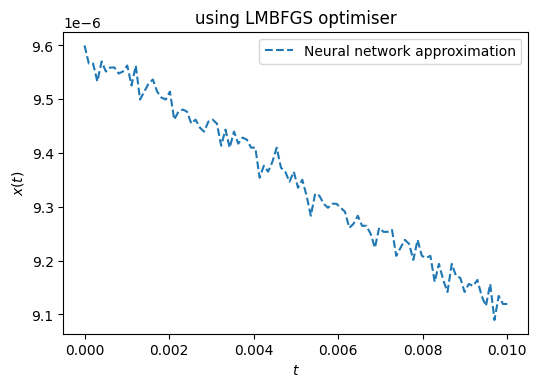

In [3]:
optimizer = torch.optim.LBFGS(N.parameters())

# The collocation points used by Lagaris
t = torch.Tensor(np.linspace(0, 2, 100)[:, None])

# Run the optimizer
def closure():
    optimizer.zero_grad()
    l = loss(t)
    l.backward()
    return l
    
for i in range(10):
    optimizer.step(closure)

xx = np.linspace(0, 0.01, 100)[:, None]
with torch.no_grad():
    yy = x(torch.Tensor(xx)).numpy()

fig, ax = plt.subplots(dpi=100)
ax.plot(xx, yy, '--', label='Neural network approximation')
ax.set_xlabel('$t$')
ax.set_ylabel('$x(t)$')
plt.title('using LMBFGS optimiser')
plt.legend(loc='best');